# Hill Climbing Algorithm - Hospital Placement Optimization

[Reference: CS50 AI - Lecture 3: Optimization](https://cs50.harvard.edu/ai/2020/weeks/3/)

---

## What is Optimization?

**Optimization** is the process of choosing the **best option from a set of options**.

In AI, we often need to find the best configuration, arrangement, or solution among many possibilities.

---

## What is Local Search?

**Local Search** is a family of search algorithms that:
- Maintain a **single node** (current state)
- Search by **moving to a neighboring node**
- Unlike BFS/DFS, we don't explore the entire search tree

### Key Difference from Previous Algorithms

| Feature | Classical Search (BFS/DFS/A*) | Local Search (Hill Climbing) |
|---------|-------------------------------|------------------------------|
| Goal | Find a **path** from start to goal | Find the **best configuration** |
| Memory | Stores many nodes (frontier) | Stores only **current state** |
| Exploration | Explores full search tree | Only looks at **neighbors** |

---

## State-Space Landscape

Imagine a landscape where:
- **X-axis** = different possible states
- **Y-axis** = value of the objective/cost function

Key terminology:

| Term | Definition |
|------|------------|
| **Objective function** | A function we want to **maximize** (find the global maximum) |
| **Cost function** | A function we want to **minimize** (find the global minimum) |
| **Current state** | Where we are right now on the landscape |
| **Neighbors** | States adjacent to the current state |
| **Local minimum** | Lower than all neighbors, but NOT the global minimum |
| **Global minimum** | The absolute lowest point across ALL states |

---

## Hill Climbing Pseudocode

```
function HILL-CLIMB(problem):
    current = initial state of problem
    repeat:
        neighbor = best valued neighbor of current
        if neighbor not better than current:
            return current
        current = neighbor
```

It works like climbing a hill in fog - you can only see your immediate neighbors, and you always move to the best one.

---

## Our Problem: Hospital Placement

**Goal:** Place hospitals on a grid so that the **total distance** from all houses to their **nearest hospital** is **minimized**.

- We have a grid of size `height x width`
- Houses are placed at fixed positions
- We need to place `num_hospitals` hospitals optimally
- **Cost** = sum of Manhattan distances from each house to its nearest hospital
- We want to **minimize** this cost

Let's build this step by step!

---

## Step 1: Setting Up the Grid (State Space)

In [20]:
# Step 1a: Define the grid dimensions
# Our state space is a 2D grid

height = 5   # number of rows
width = 8    # number of columns
num_hospitals = 2  # how many hospitals to place

print(f"Grid size: {height} rows x {width} columns")
print(f"Total cells: {height * width}")
print(f"Hospitals to place: {num_hospitals}")

Grid size: 5 rows x 8 columns
Total cells: 40
Hospitals to place: 2


Each cell on the grid is identified by a **(row, col)** tuple.
- Row 0 is the **top**, row 4 is the **bottom**
- Col 0 is the **left**, col 7 is the **right**

In [21]:
# Step 1b: Visualize the empty grid
# Each cell is represented by (row, col)

print("Our empty grid (row, col):")
print("=" * 50)
for row in range(height):
    for col in range(width):
        print(f"({row},{col})", end=" ")
    print()  # new line after each row
print("=" * 50)

Our empty grid (row, col):
(0,0) (0,1) (0,2) (0,3) (0,4) (0,5) (0,6) (0,7) 
(1,0) (1,1) (1,2) (1,3) (1,4) (1,5) (1,6) (1,7) 
(2,0) (2,1) (2,2) (2,3) (2,4) (2,5) (2,6) (2,7) 
(3,0) (3,1) (3,2) (3,3) (3,4) (3,5) (3,6) (3,7) 
(4,0) (4,1) (4,2) (4,3) (4,4) (4,5) (4,6) (4,7) 


### Step 1 Summary

| Concept | Value |
|---------|-------|
| Grid Height | 5 rows |
| Grid Width | 8 columns |
| Total Cells | 40 |
| Hospitals to place | 2 |

---

## Step 2: Placing Houses on the Grid

Houses are **fixed** - they don't move. We store them in a **set** for fast lookup.

In [22]:
# Step 2a: Create an empty set to hold house positions

houses = set()
print(f"Houses set (empty): {houses}")
print(f"Type: {type(houses)}")

Houses set (empty): set()
Type: <class 'set'>


In [23]:
# Step 2b: Add houses at specific locations
# Each house is a (row, col) tuple

houses.add((0, 1))  # House at row=0, col=1
houses.add((1, 5))  # House at row=1, col=5
houses.add((3, 2))  # House at row=3, col=2
houses.add((4, 7))  # House at row=4, col=7

print("Houses are located at:")
for h in sorted(houses):
    print(f"  House at row={h[0]}, col={h[1]}")
print(f"\nTotal houses: {len(houses)}")

Houses are located at:
  House at row=0, col=1
  House at row=1, col=5
  House at row=3, col=2
  House at row=4, col=7

Total houses: 4


Now let's create a helper function to **visualize** the grid. This will help us see houses (`H`) and hospitals (`+`) on the grid.

In [24]:
# Step 2c: Grid visualization function

def print_grid(height, width, houses, hospitals=set()):
    """Display the grid with houses and hospitals."""
    print("\n" + "=" * (width * 4 + 1))
    for row in range(height):
        print("|", end="")
        for col in range(width):
            if (row, col) in houses:
                print(" H ", end="|")       # H = House
            elif (row, col) in hospitals:
                print(" + ", end="|")       # + = Hospital
            else:
                print("   ", end="|")       # empty cell
        print()
        print("-" * (width * 4 + 1))
    print("Legend: H = House, + = Hospital")

In [25]:
# Step 2d: Visualize the grid with houses

print("Grid with 4 houses placed:")
print_grid(height, width, houses)

Grid with 4 houses placed:

|   | H |   |   |   |   |   |   |
---------------------------------
|   |   |   |   |   | H |   |   |
---------------------------------
|   |   |   |   |   |   |   |   |
---------------------------------
|   |   | H |   |   |   |   |   |
---------------------------------
|   |   |   |   |   |   |   | H |
---------------------------------
Legend: H = House, + = Hospital


### Step 2 Summary

We have **4 houses** placed on our 5x8 grid. These houses are **fixed** - they will not move. Our job is to find the **best positions** for 2 hospitals so that houses are as close as possible to their nearest hospital.

---

## Step 3: Understanding Manhattan Distance (The Cost)

**Manhattan Distance** (also called "city block distance") measures the distance between two points using only horizontal and vertical moves (no diagonals).

```
Manhattan Distance = |row1 - row2| + |col1 - col2|
```

In [26]:
# Step 3a: Define the Manhattan distance function

def manhattan_distance(point1, point2):
    """Calculate Manhattan distance between two (row, col) points."""
    return abs(point1[0] - point2[0]) + abs(point1[1] - point2[1])

In [27]:
# Step 3b: Example - distance from a house to a hospital

house = (0, 1)
hospital = (2, 3)

dist = manhattan_distance(house, hospital)

print(f"House at {house} to Hospital at {hospital}:")
print(f"  |{house[0]} - {hospital[0]}| + |{house[1]} - {hospital[1]}|")
print(f"  = |{house[0] - hospital[0]}| + |{house[1] - hospital[1]}|")
print(f"  = {abs(house[0] - hospital[0])} + {abs(house[1] - hospital[1])}")
print(f"  = {dist}")

House at (0, 1) to Hospital at (2, 3):
  |0 - 2| + |1 - 3|
  = |-2| + |-2|
  = 2 + 2
  = 4


In [28]:
# Step 3c: Try a few more examples

examples = [
    ((0, 0), (0, 5)),   # Same row, different column
    ((0, 0), (3, 0)),   # Same column, different row
    ((1, 2), (4, 6)),   # Different row and column
    ((3, 3), (3, 3)),   # Same point
]

print("More Manhattan Distance examples:")
for p1, p2 in examples:
    d = manhattan_distance(p1, p2)
    print(f"  {p1} to {p2} = {d}")

More Manhattan Distance examples:
  (0, 0) to (0, 5) = 5
  (0, 0) to (3, 0) = 3
  (1, 2) to (4, 6) = 7
  (3, 3) to (3, 3) = 0


### Now: The Cost Function

The **cost function** measures how good a hospital placement is:

```
cost = For each house:
           find distance to the NEAREST hospital
       Sum all those distances
```

**Lower cost = better placement!**

In [29]:
# Step 3d: Define the cost function

def get_cost(houses, hospitals):
    """
    For each house, find the distance to the NEAREST hospital.
    Return the sum of all those distances.
    """
    cost = 0
    for house in houses:
        # min() finds the smallest distance to any hospital
        min_dist = min(
            manhattan_distance(house, hospital)
            for hospital in hospitals
        )
        cost += min_dist
    return cost

In [30]:
# Step 3e: Let's test with hospitals at (1,1) and (3,6)

test_hospitals = {(1, 1), (3, 6)}

print("Houses:", sorted(houses))
print("Test hospitals:", sorted(test_hospitals))
print_grid(height, width, houses, test_hospitals)

Houses: [(0, 1), (1, 5), (3, 2), (4, 7)]
Test hospitals: [(1, 1), (3, 6)]

|   | H |   |   |   |   |   |   |
---------------------------------
|   | + |   |   |   | H |   |   |
---------------------------------
|   |   |   |   |   |   |   |   |
---------------------------------
|   |   | H |   |   |   | + |   |
---------------------------------
|   |   |   |   |   |   |   | H |
---------------------------------
Legend: H = House, + = Hospital


In [31]:
# Step 3f: Calculate cost step by step
# For each house, find distance to EACH hospital, pick the nearest

print("Distance from each house to nearest hospital:")
print("-" * 55)

total = 0
for house in sorted(houses):
    distances = {}
    for hosp in sorted(test_hospitals):
        d = manhattan_distance(house, hosp)
        distances[hosp] = d
    
    nearest_hosp = min(distances, key=distances.get)
    nearest_dist = distances[nearest_hosp]
    
    print(f"  House {house}:")
    for hosp, d in distances.items():
        marker = " <-- nearest" if hosp == nearest_hosp else ""
        print(f"    to hospital {hosp} = {d}{marker}")
    total += nearest_dist

print(f"\nTotal cost = {total}")
print(f"Verify with get_cost(): {get_cost(houses, test_hospitals)}")

Distance from each house to nearest hospital:
-------------------------------------------------------
  House (0, 1):
    to hospital (1, 1) = 1 <-- nearest
    to hospital (3, 6) = 8
  House (1, 5):
    to hospital (1, 1) = 4
    to hospital (3, 6) = 3 <-- nearest
  House (3, 2):
    to hospital (1, 1) = 3 <-- nearest
    to hospital (3, 6) = 4
  House (4, 7):
    to hospital (1, 1) = 9
    to hospital (3, 6) = 2 <-- nearest

Total cost = 9
Verify with get_cost(): 9


### Step 3 Summary

| Concept | Description |
|---------|-------------|
| Manhattan Distance | \|row1 - row2\| + \|col1 - col2\| |
| Cost Function | Sum of distances from each house to its **nearest** hospital |
| Goal | **Minimize** the cost function |

The cost function is what Hill Climbing will try to minimize. **Lower cost = better hospital placement.**

---

## Step 4: Neighbors - How Hospitals Can Move

A hospital can move to any of its **4 adjacent cells**:

```
          (row-1, col)     <- UP
              |
(row, col-1)--H--(row, col+1)   <- LEFT / RIGHT
              |
          (row+1, col)     <- DOWN
```

But **NOT** if the cell is:
- Outside the grid boundaries
- Already occupied by a house
- Already occupied by another hospital

In [32]:
# Step 4a: Define the get_neighbors function

def get_neighbors(row, col, height, width, houses, hospitals):
    """
    Returns valid neighboring positions for a hospital at (row, col).
    """
    # The 4 possible moves
    candidates = [
        (row - 1, col),   # UP
        (row + 1, col),   # DOWN
        (row, col - 1),   # LEFT
        (row, col + 1)    # RIGHT
    ]
    
    neighbors = []
    for r, c in candidates:
        # Skip if out of bounds
        if r < 0 or r >= height or c < 0 or c >= width:
            continue
        # Skip if occupied by house or hospital
        if (r, c) in houses or (r, c) in hospitals:
            continue
        neighbors.append((r, c))
    
    return neighbors

In [33]:
# Step 4b: Example - what are the neighbors of hospital at (1,1)?

test_pos = (1, 1)
test_hospitals = {(1, 1), (3, 6)}

print(f"Hospital at {test_pos}")
print(f"Houses at: {sorted(houses)}")
print(f"\nChecking each direction:")

directions = {
    "UP":    (test_pos[0]-1, test_pos[1]),
    "DOWN":  (test_pos[0]+1, test_pos[1]),
    "LEFT":  (test_pos[0], test_pos[1]-1),
    "RIGHT": (test_pos[0], test_pos[1]+1)
}

for direction, pos in directions.items():
    if pos in houses:
        status = "BLOCKED (house here)"
    elif pos in test_hospitals:
        status = "BLOCKED (hospital here)"
    elif pos[0] < 0 or pos[0] >= height or pos[1] < 0 or pos[1] >= width:
        status = "BLOCKED (out of bounds)"
    else:
        status = "VALID"
    print(f"  {direction:6s} -> {pos} : {status}")

Hospital at (1, 1)
Houses at: [(0, 1), (1, 5), (3, 2), (4, 7)]

Checking each direction:
  UP     -> (0, 1) : BLOCKED (house here)
  DOWN   -> (2, 1) : VALID
  LEFT   -> (1, 0) : VALID
  RIGHT  -> (1, 2) : VALID


In [34]:
# Step 4c: Get the actual valid neighbors using our function

valid = get_neighbors(*test_pos, height, width, houses, test_hospitals)
print(f"Valid neighbors of {test_pos}: {valid}")

Valid neighbors of (1, 1): [(2, 1), (1, 0), (1, 2)]


### Neighboring STATES (not just cells)

Important distinction:
- A **neighbor of a cell** = one adjacent cell
- A **neighboring state** = move **one** hospital by **one** cell, keeping other hospitals fixed

If we have hospitals at `{(1,1), (3,6)}`, a neighboring state might be `{(2,1), (3,6)}` (moved first hospital DOWN).

In [35]:
# Step 4d: Generate ALL neighboring states
# For each hospital, try moving it in each valid direction

hospitals = {(1, 1), (3, 6)}
current_cost = get_cost(houses, hospitals)

print(f"Current state: {sorted(hospitals)}")
print(f"Current cost:  {current_cost}")
print(f"\nAll neighboring states:")
print("=" * 65)

Current state: [(1, 1), (3, 6)]
Current cost:  9

All neighboring states:


In [36]:
# Step 4e: Evaluate each neighboring state

all_neighbors = []

for hospital in sorted(hospitals):
    print(f"\nMoving hospital at {hospital}:")
    
    for replacement in get_neighbors(*hospital, height, width, houses, hospitals):
        # Create new state: remove old position, add new position
        neighbor_state = hospitals.copy()
        neighbor_state.remove(hospital)
        neighbor_state.add(replacement)
        
        cost = get_cost(houses, neighbor_state)
        change = cost - current_cost
        symbol = "better" if change < 0 else "worse" if change > 0 else "same"
        
        all_neighbors.append((neighbor_state, cost))
        print(f"  -> {replacement}: state={sorted(neighbor_state)}, cost={cost} ({symbol})")


Moving hospital at (1, 1):
  -> (2, 1): state=[(2, 1), (3, 6)], cost=9 (same)
  -> (1, 0): state=[(1, 0), (3, 6)], cost=11 (worse)
  -> (1, 2): state=[(1, 2), (3, 6)], cost=9 (same)

Moving hospital at (3, 6):
  -> (2, 6): state=[(1, 1), (2, 6)], cost=9 (same)
  -> (4, 6): state=[(1, 1), (4, 6)], cost=9 (same)
  -> (3, 5): state=[(1, 1), (3, 5)], cost=9 (same)
  -> (3, 7): state=[(1, 1), (3, 7)], cost=9 (same)


In [37]:
# Step 4f: Which neighbor is the BEST?

best = min(all_neighbors, key=lambda x: x[1])

print(f"Current cost:     {current_cost}")
print(f"Best neighbor:    {sorted(best[0])}, cost = {best[1]}")
print(f"Improvement:      {current_cost - best[1]}")
print(f"\nHill Climbing would move to: {sorted(best[0])}")

Current cost:     9
Best neighbor:    [(2, 1), (3, 6)], cost = 9
Improvement:      0

Hill Climbing would move to: [(2, 1), (3, 6)]


### Step 4 Summary

| Concept | Description |
|---------|-------------|
| Neighbor of a cell | Up, Down, Left, Right (if valid) |
| Neighboring state | Move **one** hospital by **one** cell |
| Invalid neighbors | Out of bounds, occupied by house/hospital |
| Best neighbor | The neighboring state with the **lowest cost** |

At each step, Hill Climbing generates ALL neighboring states, evaluates their cost, and picks the **best** one.

---

## Step 5: Available Spaces (for Random Initialization)

Before Hill Climbing starts, we need to **randomly place hospitals** on the grid. We can only place them on **empty cells** (not where houses or other hospitals already are).

In [38]:
# Step 5a: Define the available_spaces function

def available_spaces(height, width, houses, hospitals):
    """Returns all cells not currently used by a house or hospital."""
    
    # Start with ALL cells
    candidates = set(
        (row, col)
        for row in range(height)
        for col in range(width)
    )
    
    # Remove cells with houses
    for house in houses:
        candidates.remove(house)
    
    # Remove cells with hospitals
    for hospital in hospitals:
        candidates.remove(hospital)
    
    return candidates

In [39]:
# Step 5b: How many spaces are available?

hospitals_empty = set()  # No hospitals placed yet
spaces = available_spaces(height, width, houses, hospitals_empty)

print(f"Total cells:      {height * width}")
print(f"Cells with houses: {len(houses)}")
print(f"Available spaces:  {len(spaces)}")
print(f"Check: {height * width} - {len(houses)} = {len(spaces)}")

Total cells:      40
Cells with houses: 4
Available spaces:  36
Check: 40 - 4 = 36


In [40]:
# Step 5c: Randomly place hospitals on available spaces

import random
random.seed(42)  # Fixed seed for reproducibility

hospitals = set()

# Place first hospital
space1 = random.choice(list(available_spaces(height, width, houses, hospitals)))
hospitals.add(space1)
print(f"Hospital 1 placed at: {space1}")

# Place second hospital (first hospital is now excluded from available spaces)
space2 = random.choice(list(available_spaces(height, width, houses, hospitals)))
hospitals.add(space2)
print(f"Hospital 2 placed at: {space2}")

print(f"\nInitial cost: {get_cost(houses, hospitals)}")
print_grid(height, width, houses, hospitals)

Hospital 1 placed at: (0, 5)
Hospital 2 placed at: (3, 4)

Initial cost: 11

|   | H |   |   |   | + |   |   |
---------------------------------
|   |   |   |   |   | H |   |   |
---------------------------------
|   |   |   |   |   |   |   |   |
---------------------------------
|   |   | H |   | + |   |   |   |
---------------------------------
|   |   |   |   |   |   |   | H |
---------------------------------
Legend: H = House, + = Hospital


### Step 5 Summary

Hill Climbing starts with a **random initial state**. This is usually **not optimal** - the algorithm will improve it step by step.

---

## Step 6: The Hill Climbing Algorithm

Now we put it all together! The algorithm:

1. Place hospitals **randomly** (initial state)
2. Look at **ALL** neighboring states
3. If the best neighbor is **better** than current -> **move** there
4. If **no** neighbor is better -> **STOP** (local minimum found)
5. Repeat steps 2-4

In [41]:
# Step 6a: The hill_climb function - Part 1: Random Initialization

def hill_climb(height, width, houses, num_hospitals, maximum=None, log=True):
    """
    Performs Hill Climbing to find optimal hospital placement.
    Returns: set of hospital positions
    """
    count = 0
    
    # ============================================
    # PART 1: Place hospitals randomly
    # ============================================
    hospitals = set()
    for i in range(num_hospitals):
        hospitals.add(random.choice(
            list(available_spaces(height, width, houses, hospitals))
        ))
    
    if log:
        print(f"Initial state: {sorted(hospitals)}, cost = {get_cost(houses, hospitals)}")
    
    # ============================================
    # PART 2: Iteratively improve
    # ============================================
    while maximum is None or count < maximum:
        count += 1
        
        # --- Find the best neighbor ---
        best_neighbors = []        # may have ties
        best_neighbor_cost = None
        
        for hospital in hospitals:
            for replacement in get_neighbors(*hospital, height, width, houses, hospitals):
                # Create neighboring state
                neighbor = hospitals.copy()
                neighbor.remove(hospital)
                neighbor.add(replacement)
                
                # Evaluate
                cost = get_cost(houses, neighbor)
                if best_neighbor_cost is None or cost < best_neighbor_cost:
                    best_neighbor_cost = cost
                    best_neighbors = [neighbor]
                elif cost == best_neighbor_cost:
                    best_neighbors.append(neighbor)
        
        # ============================================
        # PART 3: Decide - move or stop?
        # ============================================
        current_cost = get_cost(houses, hospitals)
        
        if best_neighbor_cost >= current_cost:
            # No improvement possible -> STOP
            if log:
                print(f"  STOP: No better neighbor (cost = {current_cost})")
            return hospitals
        else:
            # Move to best neighbor (break ties randomly)
            hospitals = random.choice(best_neighbors)
            if log:
                print(f"  Iter {count}: cost {current_cost} -> {best_neighbor_cost}")
    
    return hospitals

Let's trace through the algorithm step by step:

```
PART 1 (once):     Place hospitals RANDOMLY
                          |
                          v
PART 2 (loop):     Generate ALL neighboring states
                   Find the BEST neighbor
                          |
                          v
PART 3 (decide):   Is best neighbor BETTER than current?
                     YES -> move there, go to PART 2
                     NO  -> STOP! Return current state
```

In [42]:
# Step 6b: Run Hill Climbing!

random.seed(10)  # For reproducibility

print("Houses:", sorted(houses))
print(f"Grid: {height}x{width}, Hospitals: {num_hospitals}")
print("\n" + "=" * 55)
print("RUNNING HILL CLIMBING")
print("=" * 55)

Houses: [(0, 1), (1, 5), (3, 2), (4, 7)]
Grid: 5x8, Hospitals: 2

RUNNING HILL CLIMBING


In [43]:
# Step 6c: Execute and see the result

result = hill_climb(height, width, houses, num_hospitals, log=True)

print(f"\nFinal hospitals: {sorted(result)}")
print(f"Final cost: {get_cost(houses, result)}")
print_grid(height, width, houses, result)

Initial state: [(1, 1), (4, 3)], cost = 11
  STOP: No better neighbor (cost = 11)

Final hospitals: [(1, 1), (4, 3)]
Final cost: 11

|   | H |   |   |   |   |   |   |
---------------------------------
|   | + |   |   |   | H |   |   |
---------------------------------
|   |   |   |   |   |   |   |   |
---------------------------------
|   |   | H |   |   |   |   |   |
---------------------------------
|   |   |   | + |   |   |   | H |
---------------------------------
Legend: H = House, + = Hospital


### Step 6 Summary

Notice how the cost **decreases at each iteration** until the algorithm finds a state where **no neighbor is better** - that's the **local minimum**.

**Key insight:** Hill Climbing is **greedy** - it always moves to the best neighbor. This is fast, but it can get **stuck**!

---

## Step 7: The Problem with Hill Climbing - Local Minima

Since Hill Climbing starts **randomly**, different starting points can lead to **different results**. Some are better than others!

In [44]:
# Step 7a: Run hill climbing 5 times with different random seeds

print("Running Hill Climbing 5 times:")
print("=" * 55)

results = []
for seed in range(5):
    random.seed(seed)
    result = hill_climb(height, width, houses, num_hospitals, log=False)
    cost = get_cost(houses, result)
    results.append((seed, sorted(result), cost))
    print(f"  Seed {seed}: hospitals = {sorted(result)}, cost = {cost}")

Running Hill Climbing 5 times:
  Seed 0: hospitals = [(0, 0), (3, 5)], cost = 9
  Seed 1: hospitals = [(1, 2), (3, 7)], cost = 8
  Seed 2: hospitals = [(0, 2), (3, 1)], cost = 13
  Seed 3: hospitals = [(1, 6), (4, 5)], cost = 13
  Seed 4: hospitals = [(1, 2), (4, 6)], cost = 8


In [45]:
# Step 7b: Compare the results

best_run = min(results, key=lambda x: x[2])
worst_run = max(results, key=lambda x: x[2])

print(f"Best result:  seed {best_run[0]}, cost = {best_run[2]}")
print(f"Worst result: seed {worst_run[0]}, cost = {worst_run[2]}")
print(f"\nDifferent starting points -> different local minima!")

Best result:  seed 1, cost = 8
Worst result: seed 2, cost = 13

Different starting points -> different local minima!


### Why Does This Happen?

```
Cost
  ^                                  
  |  *                               
  | * *         *                     
  |*   *       * *                    
  |     *     *   *                   
  |      *   *     *                  
  |       * *       * *               
  |        X         * * *            
  |     Local          X              
  |     Minimum     GLOBAL            
  |                 MINIMUM           
  +-------------------------------->
                           States
```

The algorithm stops at a **local minimum** because all neighbors have higher cost, even though the **global minimum** exists elsewhere.

**Solution: Random Restart!**

---

## Step 8: Random Restart Hill Climbing

**Idea:** Run hill climbing **many times** with different random starting points, and **keep the best result**.

```
function RANDOM-RESTART(problem, max_restarts):
    best = None
    repeat max_restarts times:
        result = HILL-CLIMB(problem)
        if result is better than best:
            best = result
    return best
```

In [46]:
# Step 8a: Define random_restart function

def random_restart(height, width, houses, num_hospitals, maximum=20, log=True):
    """
    Repeats hill climbing multiple times and keeps the best result.
    """
    best_hospitals = None
    best_cost = None
    
    for i in range(maximum):
        # Run one round of hill climbing
        hospitals = hill_climb(height, width, houses, num_hospitals, log=False)
        cost = get_cost(houses, hospitals)
        
        # Is this the best so far?
        if best_cost is None or cost < best_cost:
            best_cost = cost
            best_hospitals = hospitals
            if log:
                print(f"  Restart {i+1:2d}: NEW BEST! cost = {cost}")
        else:
            if log:
                print(f"  Restart {i+1:2d}: cost = {cost} (best remains {best_cost})")
    
    return best_hospitals

In [47]:
# Step 8b: Run random restart with 20 restarts

random.seed(0)

print("RANDOM RESTART HILL CLIMBING (20 restarts)")
print("=" * 55)

best = random_restart(height, width, houses, num_hospitals, maximum=20)

RANDOM RESTART HILL CLIMBING (20 restarts)
  Restart  1: NEW BEST! cost = 9
  Restart  2: cost = 9 (best remains 9)
  Restart  3: cost = 9 (best remains 9)
  Restart  4: cost = 9 (best remains 9)
  Restart  5: NEW BEST! cost = 8
  Restart  6: cost = 13 (best remains 8)
  Restart  7: cost = 11 (best remains 8)
  Restart  8: cost = 9 (best remains 8)
  Restart  9: cost = 11 (best remains 8)
  Restart 10: cost = 9 (best remains 8)
  Restart 11: cost = 9 (best remains 8)
  Restart 12: cost = 11 (best remains 8)
  Restart 13: cost = 9 (best remains 8)
  Restart 14: cost = 8 (best remains 8)
  Restart 15: cost = 9 (best remains 8)
  Restart 16: cost = 8 (best remains 8)
  Restart 17: cost = 8 (best remains 8)
  Restart 18: cost = 11 (best remains 8)
  Restart 19: cost = 11 (best remains 8)
  Restart 20: cost = 9 (best remains 8)


In [48]:
# Step 8c: Show the best result

print(f"Best hospitals: {sorted(best)}")
print(f"Best cost: {get_cost(houses, best)}")
print_grid(height, width, houses, best)

Best hospitals: [(1, 2), (3, 7)]
Best cost: 8

|   | H |   |   |   |   |   |   |
---------------------------------
|   |   | + |   |   | H |   |   |
---------------------------------
|   |   |   |   |   |   |   |   |
---------------------------------
|   |   | H |   |   |   |   | + |
---------------------------------
|   |   |   |   |   |   |   | H |
---------------------------------
Legend: H = House, + = Hospital


### Step 8 Summary

| Approach | Description | Limitation |
|----------|-------------|------------|
| Hill Climbing | Start random, move to best neighbor | Gets stuck at local minima |
| Random Restart | Run hill climbing N times, keep best | More restarts = better chance of finding global minimum |

Random Restart is simple but effective!

---

## Step 9: The Complete Space Class

Now let's combine everything into the `Space` class (matching the original `hospitals.py` from CS50). We'll build it **method by method**.

In [49]:
# Step 9a: Class definition and __init__
# The constructor sets up the grid dimensions and empty sets

import random

class Space():
    
    def __init__(self, height, width, num_hospitals):
        """Create a new state space with given dimensions."""
        self.height = height
        self.width = width
        self.num_hospitals = num_hospitals
        self.houses = set()      # set of (row, col) tuples
        self.hospitals = set()   # set of (row, col) tuples
    
    def add_house(self, row, col):
        """Add a house at a particular location."""
        self.houses.add((row, col))
    
    def available_spaces(self):
        """Returns all cells not used by a house or hospital."""
        candidates = set(
            (row, col)
            for row in range(self.height)
            for col in range(self.width)
        )
        for house in self.houses:
            candidates.remove(house)
        for hospital in self.hospitals:
            candidates.remove(hospital)
        return candidates

print("Part 1 defined: __init__, add_house, available_spaces")

Part 1 defined: __init__, add_house, available_spaces


**What does `self` mean?**

`self` refers to the **current instance** of the class. When we write `self.height = height`, we're storing the height value **inside this specific Space object** so all methods can access it.

In [50]:
# Step 9b: Add get_cost and get_neighbors methods

class Space(Space):  # Inherit from previous definition to add methods
    
    def get_cost(self, hospitals):
        """Sum of distances from each house to its nearest hospital."""
        cost = 0
        for house in self.houses:
            cost += min(
                abs(house[0] - hospital[0]) + abs(house[1] - hospital[1])
                for hospital in hospitals
            )
        return cost
    
    def get_neighbors(self, row, col):
        """Returns valid adjacent cells (up/down/left/right)."""
        candidates = [
            (row - 1, col),   # UP
            (row + 1, col),   # DOWN
            (row, col - 1),   # LEFT
            (row, col + 1)    # RIGHT
        ]
        neighbors = []
        for r, c in candidates:
            if (r, c) in self.houses or (r, c) in self.hospitals:
                continue  # Skip occupied cells
            if 0 <= r < self.height and 0 <= c < self.width:
                neighbors.append((r, c))  # Valid!
        return neighbors

print("Part 2 defined: get_cost, get_neighbors")

Part 2 defined: get_cost, get_neighbors


In [51]:
# Step 9c: Add hill_climb method

class Space(Space):
    
    def hill_climb(self, maximum=None, log=False):
        """Performs hill-climbing to find a solution."""
        count = 0
        
        # Randomly initialize hospitals
        self.hospitals = set()
        for i in range(self.num_hospitals):
            self.hospitals.add(
                random.choice(list(self.available_spaces()))
            )
        if log:
            print(f"  Initial: cost {self.get_cost(self.hospitals)}")
        
        # Keep improving until stuck
        while maximum is None or count < maximum:
            count += 1
            best_neighbors = []
            best_neighbor_cost = None
            
            # Try moving each hospital to each valid neighbor
            for hospital in self.hospitals:
                for replacement in self.get_neighbors(*hospital):
                    neighbor = self.hospitals.copy()
                    neighbor.remove(hospital)
                    neighbor.add(replacement)
                    
                    cost = self.get_cost(neighbor)
                    if best_neighbor_cost is None or cost < best_neighbor_cost:
                        best_neighbor_cost = cost
                        best_neighbors = [neighbor]
                    elif best_neighbor_cost == cost:
                        best_neighbors.append(neighbor)
            
            # No neighbor is better -> local minimum, STOP
            if best_neighbor_cost >= self.get_cost(self.hospitals):
                return self.hospitals
            
            # Move to best neighbor
            if log:
                print(f"  Better neighbor: cost {best_neighbor_cost}")
            self.hospitals = random.choice(best_neighbors)

print("Part 3 defined: hill_climb")

Part 3 defined: hill_climb


In [52]:
# Step 9d: Add random_restart method

class Space(Space):
    
    def random_restart(self, maximum, log=False):
        """Repeats hill-climbing multiple times, keeps the best."""
        best_hospitals = None
        best_cost = None
        
        for i in range(maximum):
            hospitals = self.hill_climb()
            cost = self.get_cost(hospitals)
            
            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_hospitals = hospitals
                if log:
                    print(f"  {i}: New best! cost = {cost}")
            else:
                if log:
                    print(f"  {i}: cost = {cost} (best = {best_cost})")
        
        return best_hospitals

print("Part 4 defined: random_restart")
print("\nSpace class is complete!")

Part 4 defined: random_restart

Space class is complete!


### Space Class - Method Summary

| Method | What it does |
|--------|--------------|
| `__init__` | Creates the grid with height, width, num_hospitals |
| `add_house` | Adds a house at (row, col) |
| `available_spaces` | Returns empty cells (no house, no hospital) |
| `get_cost` | Calculates total distance from houses to nearest hospital |
| `get_neighbors` | Returns valid adjacent cells for a hospital |
| `hill_climb` | Runs hill climbing once (random start -> local minimum) |
| `random_restart` | Runs hill climbing N times, keeps the best result |

---

## Step 10: Run the Full Example

Now let's use the `Space` class with a **larger grid** (matching the original `hospitals.py`).

In [53]:
# Step 10a: Create a 10x20 grid with 3 hospitals

random.seed(42)

s = Space(height=10, width=20, num_hospitals=3)

print(f"Grid: {s.height} rows x {s.width} columns")
print(f"Hospitals to place: {s.num_hospitals}")

Grid: 10 rows x 20 columns
Hospitals to place: 3


In [54]:
# Step 10b: Add 15 random houses

for i in range(15):
    s.add_house(random.randrange(s.height), random.randrange(s.width))

print(f"Houses placed: {len(s.houses)}")
print(f"Positions: {sorted(s.houses)}")

Houses placed: 15
Positions: [(0, 2), (0, 17), (1, 0), (1, 17), (1, 18), (2, 13), (3, 4), (3, 7), (3, 17), (4, 0), (4, 7), (6, 1), (6, 7), (7, 18), (8, 19)]


In [55]:
# Step 10c: Run single Hill Climbing

print("HILL CLIMBING (single run)")
print("=" * 45)
hospitals = s.hill_climb(log=True)

print(f"\nFinal hospitals: {sorted(hospitals)}")
print(f"Final cost: {s.get_cost(hospitals)}")

HILL CLIMBING (single run)
  Initial: cost 73
  Better neighbor: cost 69
  Better neighbor: cost 67
  Better neighbor: cost 65
  Better neighbor: cost 63
  Better neighbor: cost 62
  Better neighbor: cost 61
  Better neighbor: cost 60
  Better neighbor: cost 59
  Better neighbor: cost 58

Final hospitals: [(3, 5), (3, 13), (3, 18)]
Final cost: 58


In [56]:
# Step 10d: Run Random Restart (100 restarts)

print("RANDOM RESTART (100 restarts)")
print("=" * 45)
best_hospitals = s.random_restart(maximum=100, log=True)

print(f"\nBest hospitals: {sorted(best_hospitals)}")
print(f"Best cost: {s.get_cost(best_hospitals)}")

RANDOM RESTART (100 restarts)
  0: New best! cost = 47
  1: cost = 65 (best = 47)
  2: cost = 47 (best = 47)
  3: cost = 58 (best = 47)
  4: cost = 47 (best = 47)
  5: cost = 61 (best = 47)
  6: New best! cost = 43
  7: cost = 51 (best = 43)
  8: cost = 47 (best = 43)
  9: cost = 47 (best = 43)
  10: cost = 47 (best = 43)
  11: cost = 73 (best = 43)
  12: cost = 65 (best = 43)
  13: cost = 56 (best = 43)
  14: cost = 56 (best = 43)
  15: cost = 51 (best = 43)
  16: cost = 49 (best = 43)
  17: cost = 49 (best = 43)
  18: cost = 47 (best = 43)
  19: cost = 53 (best = 43)
  20: cost = 56 (best = 43)
  21: cost = 63 (best = 43)
  22: cost = 58 (best = 43)
  23: cost = 43 (best = 43)
  24: cost = 63 (best = 43)
  25: cost = 49 (best = 43)
  26: cost = 51 (best = 43)
  27: cost = 47 (best = 43)
  28: cost = 49 (best = 43)
  29: cost = 51 (best = 43)
  30: cost = 49 (best = 43)
  31: cost = 51 (best = 43)
  32: cost = 47 (best = 43)
  33: cost = 70 (best = 43)
  34: cost = 51 (best = 43)
  35

---

## Step 11: Visualize the Result

Let's use **matplotlib** to create a nice visual of the final hospital placement.

In [57]:
# Step 11a: Import visualization libraries

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("matplotlib imported successfully")

matplotlib imported successfully


In [58]:
# Step 11b: Define the visualization function

def visualize_grid(space, hospitals, title="Hospital Placement"):
    """Visualize the grid with houses and hospitals."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Draw grid cells (black background)
    for row in range(space.height):
        for col in range(space.width):
            rect = plt.Rectangle(
                (col, space.height - 1 - row), 1, 1,
                linewidth=0.5, edgecolor='gray', facecolor='black'
            )
            ax.add_patch(rect)
    
    # Draw houses (blue squares with 'H')
    for (row, col) in space.houses:
        rect = plt.Rectangle(
            (col + 0.1, space.height - 1 - row + 0.1), 0.8, 0.8,
            linewidth=1, edgecolor='white', facecolor='#2196F3'
        )
        ax.add_patch(rect)
        ax.text(col + 0.5, space.height - 1 - row + 0.5, 'H',
                ha='center', va='center', color='white',
                fontsize=10, fontweight='bold')
    
    # Draw hospitals (red squares with '+')
    for (row, col) in hospitals:
        rect = plt.Rectangle(
            (col + 0.1, space.height - 1 - row + 0.1), 0.8, 0.8,
            linewidth=1, edgecolor='white', facecolor='#F44336'
        )
        ax.add_patch(rect)
        ax.text(col + 0.5, space.height - 1 - row + 0.5, '+',
                ha='center', va='center', color='white',
                fontsize=16, fontweight='bold')
    
    # Draw dashed lines from each house to its nearest hospital
    for house in space.houses:
        nearest = min(
            hospitals,
            key=lambda h: abs(house[0]-h[0]) + abs(house[1]-h[1])
        )
        ax.plot(
            [house[1]+0.5, nearest[1]+0.5],
            [space.height-1-house[0]+0.5, space.height-1-nearest[0]+0.5],
            'yellow', linewidth=1, alpha=0.5, linestyle='--'
        )
    
    # Formatting
    cost = space.get_cost(hospitals)
    ax.set_xlim(0, space.width)
    ax.set_ylim(0, space.height)
    ax.set_aspect('equal')
    ax.set_title(f"{title} (Cost: {cost})",
                 fontsize=14, fontweight='bold', color='white')
    ax.set_facecolor('black')
    fig.patch.set_facecolor('#1a1a1a')
    
    # Legend
    house_patch = mpatches.Patch(color='#2196F3', label='House (H)')
    hosp_patch = mpatches.Patch(color='#F44336', label='Hospital (+)')
    ax.legend(handles=[house_patch, hosp_patch], loc='upper right',
              facecolor='#333333', edgecolor='white', labelcolor='white')
    
    ax.set_xticks(range(space.width))
    ax.set_yticks(range(space.height))
    ax.tick_params(colors='white')
    plt.tight_layout()
    plt.show()

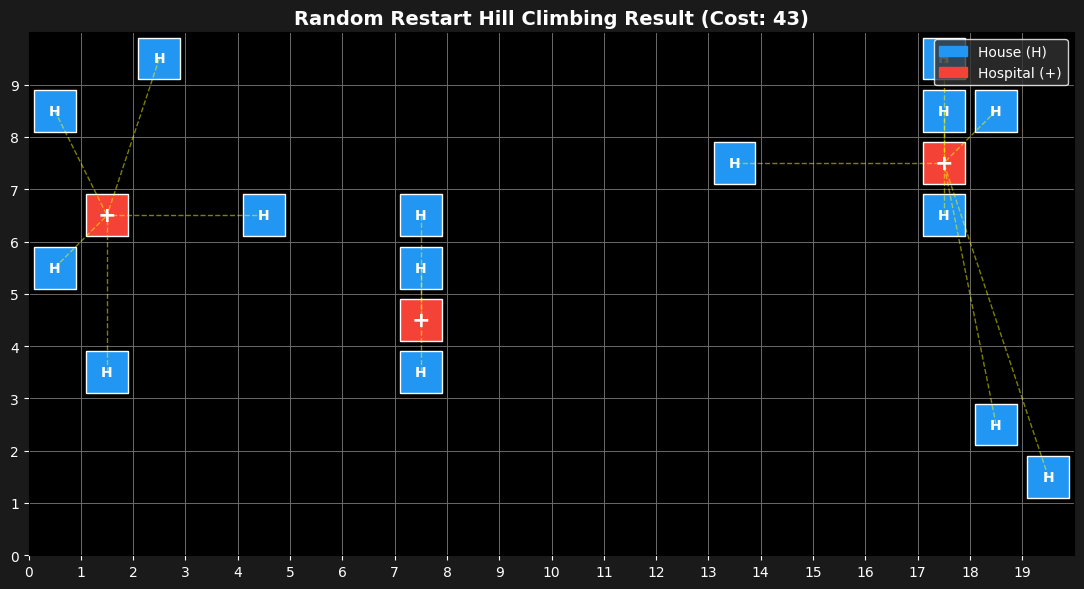

In [59]:
# Step 11c: Visualize the result!

visualize_grid(s, best_hospitals, "Random Restart Hill Climbing Result")

The **yellow dashed lines** show which hospital each house is closest to. The hospitals have moved near **clusters of houses** to minimize total distance.

---

## Step 12: Compare Single Hill Climb vs Random Restart

Let's run both approaches **50 times each** and compare the results.

In [60]:
# Step 12a: Create a fresh Space for comparison

s2 = Space(height=10, width=20, num_hospitals=3)
random.seed(42)
for i in range(15):
    s2.add_house(random.randrange(s2.height), random.randrange(s2.width))

print(f"Grid: {s2.height}x{s2.width}, Houses: {len(s2.houses)}, Hospitals: {s2.num_hospitals}")

Grid: 10x20, Houses: 15, Hospitals: 3


In [61]:
# Step 12b: Run 50 single hill climbs

single_costs = []
for i in range(50):
    result = s2.hill_climb()
    single_costs.append(s2.get_cost(result))

print(f"Single Hill Climbing (50 runs):")
print(f"  Average cost: {sum(single_costs)/len(single_costs):.1f}")
print(f"  Best cost:    {min(single_costs)}")
print(f"  Worst cost:   {max(single_costs)}")

Single Hill Climbing (50 runs):
  Average cost: 53.7
  Best cost:    43
  Worst cost:   73


In [62]:
# Step 12c: Run 50 random-restart hill climbs (20 restarts each)

restart_costs = []
for i in range(50):
    result = s2.random_restart(maximum=20)
    restart_costs.append(s2.get_cost(result))

print(f"Random Restart (50 runs, 20 restarts each):")
print(f"  Average cost: {sum(restart_costs)/len(restart_costs):.1f}")
print(f"  Best cost:    {min(restart_costs)}")
print(f"  Worst cost:   {max(restart_costs)}")

Random Restart (50 runs, 20 restarts each):
  Average cost: 43.5
  Best cost:    43
  Worst cost:   47


In [63]:
# Step 12d: Side-by-side comparison

print("COMPARISON")
print("=" * 55)
print(f"{'Metric':<20} {'Single HC':>15} {'Random Restart':>15}")
print("-" * 55)
print(f"{'Average cost':<20} {sum(single_costs)/len(single_costs):>15.1f} {sum(restart_costs)/len(restart_costs):>15.1f}")
print(f"{'Best cost':<20} {min(single_costs):>15} {min(restart_costs):>15}")
print(f"{'Worst cost':<20} {max(single_costs):>15} {max(restart_costs):>15}")

COMPARISON
Metric                     Single HC  Random Restart
-------------------------------------------------------
Average cost                    53.7            43.5
Best cost                         43              43
Worst cost                        73              47


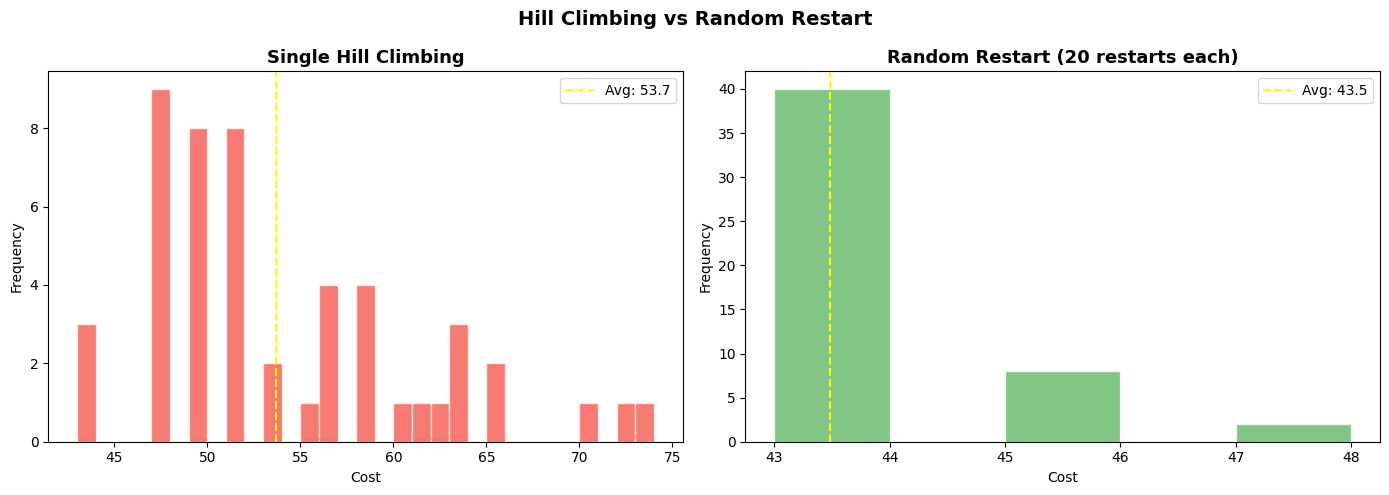

In [64]:
# Step 12e: Plot the comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Single Hill Climbing
axes[0].hist(single_costs,
             bins=range(min(single_costs), max(single_costs) + 2),
             color='#F44336', alpha=0.7, edgecolor='white')
axes[0].set_title('Single Hill Climbing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cost')
axes[0].set_ylabel('Frequency')
avg1 = sum(single_costs) / len(single_costs)
axes[0].axvline(avg1, color='yellow', linestyle='--',
                label=f'Avg: {avg1:.1f}')
axes[0].legend()

# Right: Random Restart
axes[1].hist(restart_costs,
             bins=range(min(restart_costs), max(restart_costs) + 2),
             color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1].set_title('Random Restart (20 restarts each)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cost')
axes[1].set_ylabel('Frequency')
avg2 = sum(restart_costs) / len(restart_costs)
axes[1].axvline(avg2, color='yellow', linestyle='--',
                label=f'Avg: {avg2:.1f}')
axes[1].legend()

plt.suptitle('Hill Climbing vs Random Restart',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### What the Histograms Show

- **Left (Red):** Single Hill Climbing - costs are **spread out** (many different local minima)
- **Right (Green):** Random Restart - costs are **concentrated lower** (consistently finds better solutions)

Random Restart produces **more reliable** and **better** results!

---

## Summary: Key Concepts

| Concept | Description |
|---------|-------------|
| **Optimization** | Choosing the best option from a set of options |
| **Local Search** | Search by maintaining a single state, moving to neighbors |
| **State** | A configuration (e.g., positions of all hospitals) |
| **Neighbor** | A state reachable by a small change (move one hospital one cell) |
| **Cost Function** | What we minimize (sum of house-to-nearest-hospital distances) |
| **Hill Climbing** | Always move to the best neighbor; stop when no improvement |
| **Local Minimum** | A state better than all neighbors, but not globally optimal |
| **Random Restart** | Run hill climbing many times, keep the best result |

### Hill Climbing Pseudocode (Final)

```
function HILL-CLIMB(problem):
    current = initial state of problem
    repeat:
        neighbor = best valued neighbor of current
        if neighbor not better than current:
            return current
        current = neighbor
```

### Hill Climbing Variants

| Variant | Description |
|---------|-------------|
| **Steepest-ascent** | Pick the single best neighbor (what we implemented) |
| **Stochastic** | Pick randomly among better neighbors |
| **First-choice** | Pick the first neighbor that is better |
| **Random Restart** | Run hill climbing multiple times |
| **Simulated Annealing** | Sometimes accept worse neighbors (covered in lecture) |